In [1]:
import os

base = '/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo'

for root, dirs, files_ in os.walk(base):
    if len(files_) > 0:
        print(f"{root}/ ({len(files_)} files)")

/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/ (1 files)
/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/val/labels/ (3099 files)
/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/val/images/ (3099 files)
/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/test/labels/ (4306 files)
/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/test/images/ (4306 files)
/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/train/labels/ (14122 files)
/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data/train/images/ (14122 files)


In [2]:
!pip install ultralytics albumentations -q

import os
import cv2
import json
import random
import numpy as np
import matplotlib.pyplot as plt
import albumentations as A
from collections import Counter
from PIL import Image

print("All libraries imported successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 17.6 MB/s eta 0:00:00
All libraries imported successfully!


In [3]:
DATASET_ROOT = '/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo'
CLASS_NAMES  = ['smoke', 'fire']
OUTPUT_DIR   = '/kaggle/working'

TRAIN_IMG = os.path.join(DATASET_ROOT, 'data/train/images')
TRAIN_LBL = os.path.join(DATASET_ROOT, 'data/train/labels')
VAL_IMG   = os.path.join(DATASET_ROOT, 'data/val/images')
VAL_LBL   = os.path.join(DATASET_ROOT, 'data/val/labels')
TEST_IMG  = os.path.join(DATASET_ROOT, 'data/test/images')
TEST_LBL  = os.path.join(DATASET_ROOT, 'data/test/labels')

print("Verifying paths...")
all_good = True
for name, path in [
    ('Train images', TRAIN_IMG), ('Train labels', TRAIN_LBL),
    ('Val images',   VAL_IMG),   ('Val labels',   VAL_LBL),
    ('Test images',  TEST_IMG),  ('Test labels',  TEST_LBL),
]:
    if os.path.exists(path):
        count = len(os.listdir(path))
        print(f"  {name:15s}: {count} files")
    else:
        print(f"  {name:15s}: PATH NOT FOUND")
        all_good = False

if all_good:
    print("\nAll paths verified!")
else:
    print("\nSome paths missing — paste output here!")

Verifying paths...
  Train images   : 14122 files
  Train labels   : 14122 files
  Val images     : 3099 files
  Val labels     : 3099 files
  Test images    : 4306 files
  Test labels    : 4306 files

All paths verified!


In [4]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

yaml_content = f"""path: {DATASET_ROOT}
train: data/train/images
val: data/val/images
test: data/test/images

nc: 2
names: ['smoke', 'fire']
"""

yaml_path = os.path.join(OUTPUT_DIR, 'dfire_dataset.yaml')
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

print("YAML saved at:", yaml_path)
print(yaml_content)

YAML saved at: /kaggle/working/dfire_dataset.yaml
path: /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo
train: data/train/images
val: data/val/images
test: data/test/images

nc: 2
names: ['smoke', 'fire']



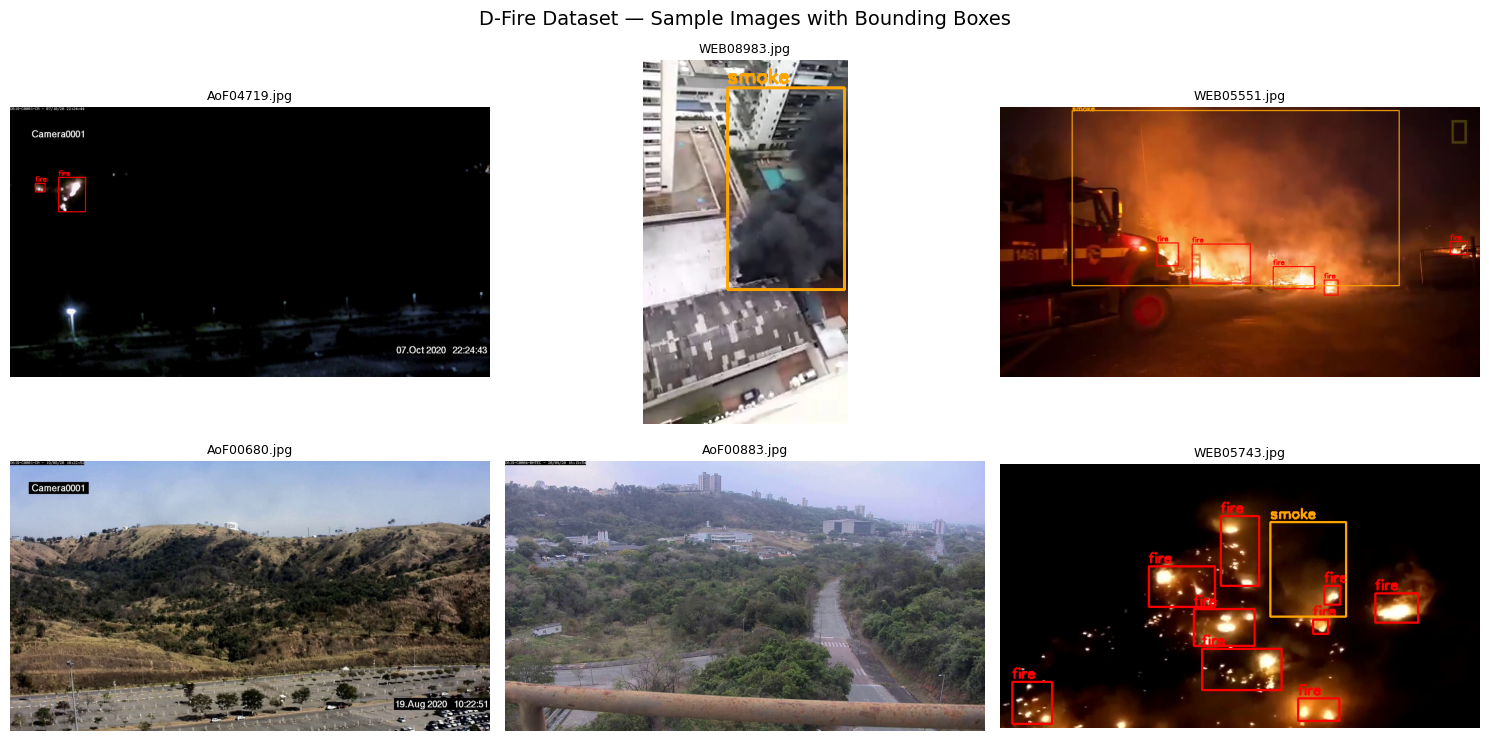

Saved to /kaggle/working/sample_images.png


In [5]:
CLASS_COLORS = [(255, 165, 0), (255, 0, 0)]  # orange=smoke, red=fire

def draw_yolo_boxes(img_path, lbl_path):
    img = cv2.imread(img_path)
    if img is None:
        return np.zeros((640, 640, 3), dtype=np.uint8)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    if os.path.exists(lbl_path):
        with open(lbl_path) as f:
            lines = f.readlines()
        for line in lines:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls            = int(parts[0])
            cx, cy, bw, bh = map(float, parts[1:])
            x1 = int((cx - bw/2) * w)
            y1 = int((cy - bh/2) * h)
            x2 = int((cx + bw/2) * w)
            y2 = int((cy + bh/2) * h)
            color = CLASS_COLORS[cls]
            cv2.rectangle(img, (x1,y1), (x2,y2), color, 2)
            cv2.putText(img, CLASS_NAMES[cls],
                        (x1, max(y1-5, 10)),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.6, color, 2)
    return img

# Pick 6 random training images
img_files = [f for f in os.listdir(TRAIN_IMG)
             if f.endswith(('.jpg','.png','.jpeg'))]
samples = random.sample(img_files, 6)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('D-Fire Dataset — Sample Images with Bounding Boxes',
             fontsize=14)

for ax, fname in zip(axes.flatten(), samples):
    img_path = os.path.join(TRAIN_IMG, fname)
    lbl_path = os.path.join(TRAIN_LBL,
                 fname.replace('.jpg', '.txt')
                      .replace('.png', '.txt')
                      .replace('.jpeg','.txt'))
    img = draw_yolo_boxes(img_path, lbl_path)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(fname[:25], fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'sample_images.png'), dpi=100)
plt.show()
print("Saved to /kaggle/working/sample_images.png")

Counting labels (takes ~1 min)...

=== TRAIN SET ===
  smoke        : 7794
  fire         : 9638
  empty frames : 6458

=== VAL SET ===
  smoke        : 1756
  fire         : 2176
  empty frames : 1375

=== TEST SET ===
  smoke        : 2315
  fire         : 2878
  empty frames : 2005


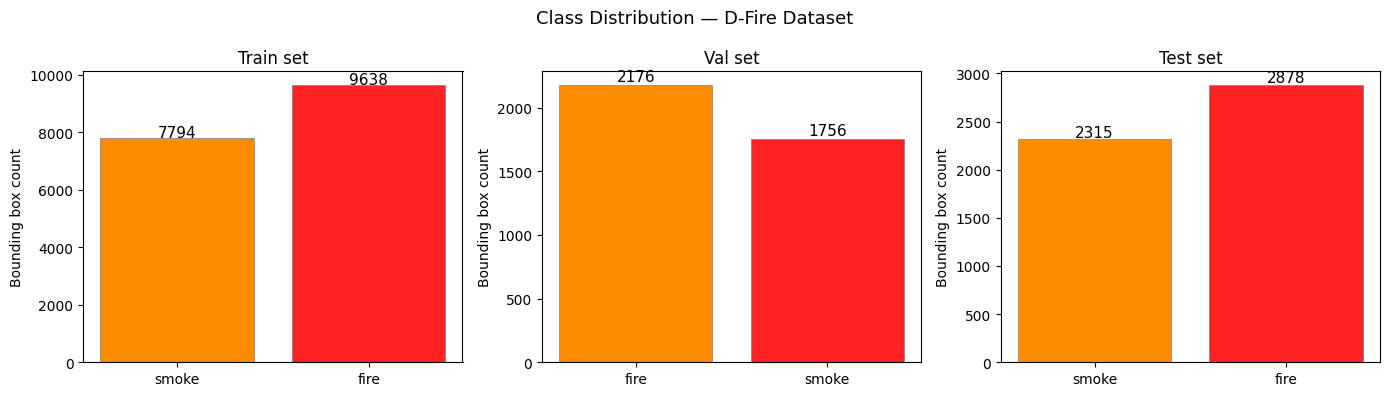

Saved to /kaggle/working/class_distribution.png


In [6]:
def count_labels(label_dir):
    counts = Counter()
    empty  = 0
    for fname in os.listdir(label_dir):
        if not fname.endswith('.txt'):
            continue
        fpath = os.path.join(label_dir, fname)
        with open(fpath) as f:
            lines = f.readlines()
        if not lines:
            empty += 1
        for line in lines:
            parts = line.strip().split()
            if parts:
                cls = int(parts[0])
                counts[CLASS_NAMES[cls]] += 1
    return counts, empty

print("Counting labels (takes ~1 min)...")
train_counts, train_empty = count_labels(TRAIN_LBL)
val_counts,   val_empty   = count_labels(VAL_LBL)
test_counts,  test_empty  = count_labels(TEST_LBL)

print(f"\n=== TRAIN SET ===")
print(f"  smoke        : {train_counts['smoke']}")
print(f"  fire         : {train_counts['fire']}")
print(f"  empty frames : {train_empty}")

print(f"\n=== VAL SET ===")
print(f"  smoke        : {val_counts['smoke']}")
print(f"  fire         : {val_counts['fire']}")
print(f"  empty frames : {val_empty}")

print(f"\n=== TEST SET ===")
print(f"  smoke        : {test_counts['smoke']}")
print(f"  fire         : {test_counts['fire']}")
print(f"  empty frames : {test_empty}")

# Plot all 3 splits
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (counts, title) in zip(axes, [
    (train_counts, 'Train set'),
    (val_counts,   'Val set'),
    (test_counts,  'Test set'),
]):
    bars = ax.bar(
        counts.keys(), counts.values(),
        color=['#FF8C00', '#FF2222'],
        edgecolor='gray', linewidth=0.5
    )
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Bounding box count')
    for bar, (k, v) in zip(bars, counts.items()):
        ax.text(bar.get_x() + bar.get_width()/2,
                v + 30, str(v), ha='center', fontsize=11)

plt.suptitle('Class Distribution — D-Fire Dataset', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'class_distribution.png'), dpi=100)
plt.show()
print("Saved to /kaggle/working/class_distribution.png")

Checking image sizes...


100%|██████████| 500/500 [00:07<00:00, 65.37it/s]



Image size stats (sample of 500 images):
  Width  — min:202 max:3264 avg:994
  Height — min:180 max:2448 avg:585


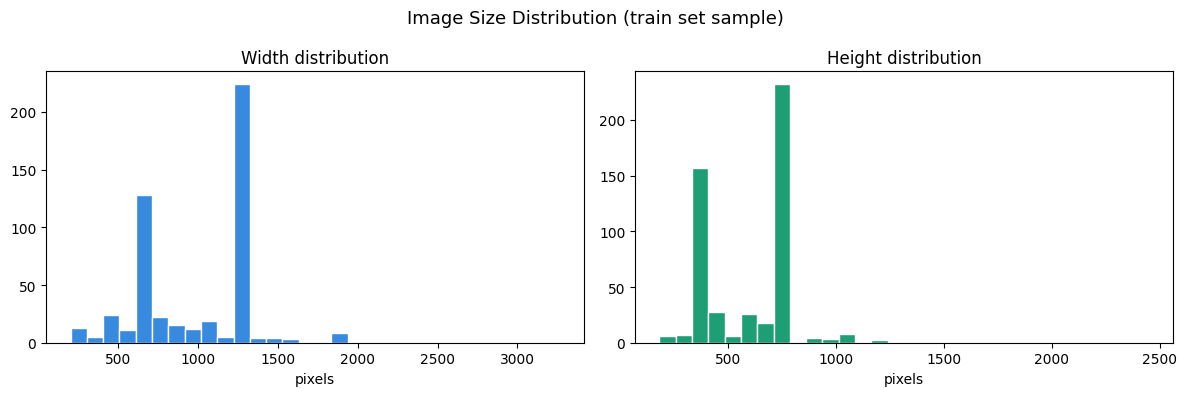

In [7]:
from tqdm import tqdm

print("Checking image sizes...")
widths, heights = [], []

sample_check = random.sample(img_files, min(500, len(img_files)))
for fname in tqdm(sample_check):
    fpath = os.path.join(TRAIN_IMG, fname)
    img   = cv2.imread(fpath)
    if img is not None:
        h, w = img.shape[:2]
        widths.append(w)
        heights.append(h)

print(f"\nImage size stats (sample of {len(widths)} images):")
print(f"  Width  — min:{min(widths)} max:{max(widths)} avg:{int(np.mean(widths))}")
print(f"  Height — min:{min(heights)} max:{max(heights)} avg:{int(np.mean(heights))}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths,  bins=30, color='#378ADD', edgecolor='white')
axes[0].set_title('Width distribution')
axes[0].set_xlabel('pixels')
axes[1].hist(heights, bins=30, color='#1D9E75', edgecolor='white')
axes[1].set_title('Height distribution')
axes[1].set_xlabel('pixels')
plt.suptitle('Image Size Distribution (train set sample)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'size_distribution.png'), dpi=100)
plt.show()

/tmp/ipykernel_17/2992276729.py:6: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10, 50), p=0.3),


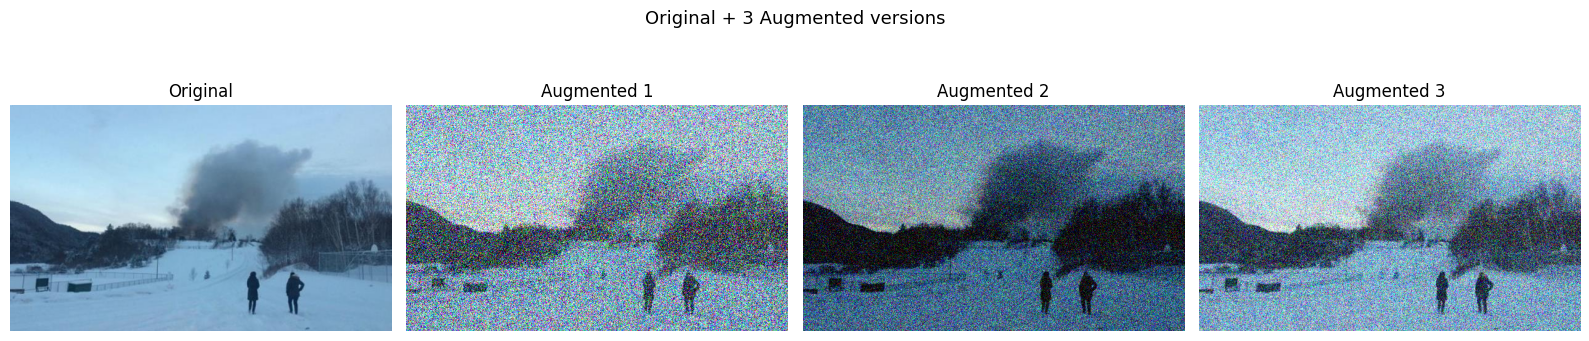

Saved to /kaggle/working/augmentation_preview.png


In [8]:
augment = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(
        brightness_limit=0.3,
        contrast_limit=0.3, p=0.5),
    A.GaussNoise(var_limit=(10, 50), p=0.3),
    A.RandomFog(fog_coef_range=(0.1, 0.3), p=0.2),
    A.HueSaturationValue(
        hue_shift_limit=10,
        sat_shift_limit=20, p=0.3),
], bbox_params=A.BboxParams(
    format='yolo',
    label_fields=['class_labels'],
    min_visibility=0.3))

# Pick a sample that has labels
sample_fname = None
for fname in random.sample(img_files, 50):
    lbl = os.path.join(TRAIN_LBL,
              fname.replace('.jpg','.txt')
                   .replace('.png','.txt')
                   .replace('.jpeg','.txt'))
    if os.path.exists(lbl) and os.path.getsize(lbl) > 0:
        sample_fname = fname
        break

sample_img_path = os.path.join(TRAIN_IMG, sample_fname)
sample_lbl_path = os.path.join(TRAIN_LBL,
    sample_fname.replace('.jpg', '.txt')
                .replace('.png', '.txt')
                .replace('.jpeg','.txt'))

img    = cv2.imread(sample_img_path)
img    = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
bboxes, labels = [], []

with open(sample_lbl_path) as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) == 5:
            labels.append(int(parts[0]))
            bboxes.append(list(map(float, parts[1:])))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Original + 3 Augmented versions', fontsize=13)
axes[0].imshow(img)
axes[0].set_title('Original')
axes[0].axis('off')

for i in range(1, 4):
    try:
        aug = augment(image=img,
                      bboxes=bboxes,
                      class_labels=labels)
        axes[i].imshow(aug['image'])
        axes[i].set_title(f'Augmented {i}')
    except Exception as e:
        axes[i].set_title('Skipped')
    axes[i].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'augmentation_preview.png'), dpi=100)
plt.show()
print("Saved to /kaggle/working/augmentation_preview.png")

In [9]:
config = {
    'DATASET_ROOT' : DATASET_ROOT,
    'TRAIN_IMG'    : TRAIN_IMG,
    'TRAIN_LBL'    : TRAIN_LBL,
    'VAL_IMG'      : VAL_IMG,
    'VAL_LBL'      : VAL_LBL,
    'TEST_IMG'     : TEST_IMG,
    'TEST_LBL'     : TEST_LBL,
    'YAML_PATH'    : yaml_path,
    'CLASS_NAMES'  : CLASS_NAMES,
    'OUTPUT_DIR'   : OUTPUT_DIR,
    'IMG_SIZE'     : 640,
}

config_path = os.path.join(OUTPUT_DIR, 'config.json')
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)

print("=" * 45)
print("  Notebook 1 COMPLETE!")
print("=" * 45)
print(f"\nFiles saved to {OUTPUT_DIR}:")
for f in os.listdir(OUTPUT_DIR):
    size = os.path.getsize(os.path.join(OUTPUT_DIR, f))
    print(f"  {f:35s} {size/1024:.1f} KB")

  Notebook 1 COMPLETE!

Files saved to /kaggle/working:
  augmentation_preview.png            924.6 KB
  dfire_dataset.yaml                  0.2 KB
  sample_images.png                   912.5 KB
  __notebook__.ipynb                  2553.9 KB
  size_distribution.png               22.6 KB
  config.json                         0.8 KB
  class_distribution.png              35.5 KB
